# **Phase 1: Raw Data Diagnosis (EDA)**
## Exploratory Data Analysis - CDE Hate Crimes Dataset 2024

<span style="color: #be5e00">**Objective:**</span> Detect errors, missing values and inconsistencies in decoded data (bh_decoded and ir_decoded) to provide evidence for why Data Preparation is needed.

<span style="color: #be5e00">**Method:**</span>
- Use `.info()`, `.describe()`, `.isna().sum()` to check data structure and quality
- Visualize raw data to demonstrate issues
- Summarize 5+ main issues that need handling in Phase 2
- Analyze both datasets: BH (Behavioral Health) and IR (Incident Reports)

---

## **1. Import Libraries and Load Data**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0] 
sys.path.append(str(PROJECT_ROOT))

from src.load_data import load_all_raw

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set max columns to display
pd.set_option('display.max_columns', None)

# Create folder for images
os.makedirs(PROJECT_ROOT / 'images/images_before', exist_ok=True)

In [54]:
# Load raw data
bh_raw, ir_raw = load_all_raw()

# Load decoded Batch Header data
bh_path = '../data/interim/bh_decoded.parquet'
bh_decoded = pd.read_parquet(bh_path)

print("Decoded Batch Header data loaded successfully!")
print(f"  - Rows: {bh_decoded.shape[0]:,}")
print(f"  - Columns: {bh_decoded.shape[1]}")

# Load decoded Incident Report data
ir_path = '../data/interim/ir_decoded.parquet'
ir_decoded = pd.read_parquet(ir_path)

print("Decoded Incident Report data loaded successfully!")
print(f"  - Rows: {ir_decoded.shape[0]:,}")
print(f"  - Columns: {ir_decoded.shape[1]}")


📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2021_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,064 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2022_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,898 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2023_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 12,034 IR records.

📁 Reading file: D:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\data\raw\2024_HC_NATIONAL_MASTER_FILE.txt
  ✅ Parsed 26,136 BH records, 11,679 IR records.
 TOTAL RECORDS LOADED:
   BH (Agency) records: 104,544
   IR (Incident) records: 46,675
Decoded Batch Header data loaded successfully!
  - Rows: 104,544
  - Columns: 55
Decoded Incident Report data loaded successfully!
  - Rows: 46,675
  - Columns: 169


## **2. Data Structure Exploration**

## 1. Raw Data Status (Encoding Issues)

In [55]:
print("\n" + "="*80)
print("\t\tDETAILED RAW DATA SAMPLE")
print("="*80)

print("\n[BH RAW DATA] Actual raw bytes from fixed-width file:")
print("-" * 80)
if bh_raw is not None and len(bh_raw) > 0:
    print(f"Data Shape: {bh_raw.shape}")
    print(f"Columns: {bh_raw.columns.tolist()}")
    print("\nFirst 2 rows (raw format - notice encoding issues):")
    print(bh_raw.head(2).to_string())
    print(f"\nData Type: {bh_raw.dtypes.unique()}")
else:
    print("Unable to display - raw data not loaded properly")

print("\n" + "-" * 80)
print("\n[IR RAW DATA] Actual raw bytes from fixed-width file:")
print("-" * 80)
if ir_raw is not None and len(ir_raw) > 0:
    print(f"Data Shape: {ir_raw.shape}")
    print(f"Columns: {ir_raw.columns.tolist()}")
    print("\nFirst 2 rows (raw format - notice encoding issues):")
    print(ir_raw.head(2).to_string())
    print(f"\nData Type: {ir_raw.dtypes.unique()}")
else:
    print("Unable to display - raw data not loaded properly")

print("\n" + "=" * 80)


		DETAILED RAW DATA SAMPLE

[BH RAW DATA] Actual raw bytes from fixed-width file:
--------------------------------------------------------------------------------
Data Shape: (104544, 54)
Columns: ['record_type', 'state_code', 'ori', 'date_ori_added', 'date_ori_went_nibrs', 'city_name', 'state_abbr', 'population_group', 'country_division', 'country_region', 'agency_indicator', 'core_city', 'covered_by_ori', 'fbi_field_office', 'judicial_district', 'nibrs_flag', 'inactive_date', 'current_population_1', 'ucr_county_code_1', 'msa_code_1', 'last_population_1', 'current_population_2', 'ucr_county_code_2', 'msa_code_2', 'last_population_2', 'current_population_3', 'ucr_county_code_3', 'msa_code_3', 'last_population_3', 'current_population_4', 'ucr_county_code_4', 'msa_code_4', 'last_population_4', 'current_population_5', 'ucr_county_code_5', 'msa_code_5', 'last_population_5', 'master_file_year', 'state_q1_activity', 'state_q2_activity', 'state_q3_activity', 'state_q4_activity', 'federal_q1_

### RAW DATA PROBLEMS:

1. **Fixed-Width Text Format**: Data is stored in fixed-width positions
   - Each field has a fixed number of characters
   - No delimiters (commas, tabs) between fields
   - Values are padded with spaces
   
2. **Code-Based Issues**:
   - Human-readable at the text level, but semantically encoded, requiring a codebook to interpret.

3. **Data Structure is Opaque**:
   - No column headers in raw files
   - No way to know field boundaries without documentation
   - Looks like a continuous stream of characters
   
4. **Solution - Decoding Pipeline**:
   - Step 1: Parse fixed-width fields using column positions from documentation
   - Step 2: Map coded numeric values to human-readable descriptions
   - Step 3: Convert to UTF-8 and save as structured .parquet format
   
5. **Result**: Decoded files (bh_decoded.parquet, ir_decoded.parquet)
   - ✓ Proper UTF-8 encoding
   - ✓ Structured columns with headers
   - ✓ Human-readable descriptions instead of codes
   - ✓ Ready for further processing and analysis.

## 2. Decoded Data Structure Exploration - BH Dataset

In [56]:
print("="*80)
print("DATA OVERVIEW")
print("="*80)
bh_decoded.info()

DATA OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104544 entries, 0 to 104543
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   record_type           104544 non-null  object
 1   state_code            104544 non-null  object
 2   ori                   104544 non-null  object
 3   date_ori_added        104544 non-null  object
 4   date_ori_went_nibrs   104544 non-null  object
 5   city_name             104544 non-null  object
 6   state_abbr            104544 non-null  object
 7   population_group      103164 non-null  object
 8   country_division      104544 non-null  object
 9   country_region        103164 non-null  object
 10  agency_type           101012 non-null  object
 11  is_core_city          103164 non-null  object
 12  covered_by_ori        104544 non-null  object
 13  fbi_field_office      104544 non-null  object
 14  judicial_district     101932 non-null  object
 15  is_

In [57]:
print("\n" + "="*80)
print("BH AGENCIES - BASIC STATISTICS (.describe())")
print("="*80)

print("\nNUMERIC COLUMNS:")
print(bh_decoded.describe().T)
print("\nCATEGORICAL COLUMNS:")
print(bh_decoded.describe(include='object').T)


BH AGENCIES - BASIC STATISTICS (.describe())

NUMERIC COLUMNS:
             count     mean          std  min      25%      50%       75%  \
bh_index  104544.0  13067.5  7544.849397  0.0  6533.75  13067.5  19601.25   

              max  
bh_index  26135.0  

CATEGORICAL COLUMNS:
                       count unique                             top    freq
record_type           104544      1                              BH  104544
state_code            104544     58                              37    8592
ori                   104544  26136                       AK0010100       4
date_ori_added        104544      1                                  104544
date_ori_went_nibrs   104544    410                                   37180
city_name             104544   9025                                   15120
state_abbr            104544     58                              PA    8592
population_group      103164     20                   Cities <2,500   35707
country_division      104544     11

In [85]:
print("\n" + "="*80)
print("BH AGENCIES - MISSING VALUES ANALYSIS")
print("="*80)

# base missing mask: actual NaN OR any whitespace-only string
base_mask = bh_decoded.apply(
    lambda col: col.isna() | (col.astype(str).str.strip() == '')
)

mask_missing_bh = base_mask.copy()

# Add condition: for population columns, value == 0 is also missing
population_cols = bh_decoded.columns.str.contains('population', case=False)

if population_cols.any():
    # take population columns as strings, strip whitespace, convert to numeric
    numeric_pop = bh_decoded.loc[:, population_cols].astype(str).apply(lambda s: s.str.strip())
    numeric_pop = numeric_pop.apply(pd.to_numeric, errors='coerce')
    # treat conversion failures (NaN) or 0 as missing
    pop_missing = numeric_pop.isna() | (numeric_pop == 0)
    # update the mask for population columns
    mask_missing_bh.loc[:, population_cols] = mask_missing_bh.loc[:, population_cols] | pop_missing

bh_missing_data = pd.DataFrame({
    'Column': bh_decoded.columns,
    'Missing Count': mask_missing_bh.sum(),
    'Percentage (%)': (mask_missing_bh.sum() / len(bh_decoded) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print(bh_missing_data.to_string(index=False))
print(f"\nTotal missing values in BH dataset: {mask_missing_bh.sum().sum()}")


BH AGENCIES - MISSING VALUES ANALYSIS
              Column  Missing Count  Percentage (%)
   last_population_1         104544          100.00
current_population_5         104544          100.00
   last_population_3         104544          100.00
   last_population_4         104544          100.00
   last_population_2         104544          100.00
    population_group         104544          100.00
     fips_counties_5         104544          100.00
   ucr_county_code_5         104544          100.00
          msa_code_5         104544          100.00
      date_ori_added         104544          100.00
   last_population_5         104544          100.00
          msa_code_4         104510           99.97
   ucr_county_code_4         104510           99.97
current_population_4         104510           99.97
     fips_counties_4         104510           99.97
   ucr_county_code_3         104282           99.75
current_population_3         104282           99.75
          msa_code_3     

## 3. Decoded Data Structure Exploration - IR Dataset

In [59]:
print("\n" + "="*80)
print("IR INCIDENTS DATA - OVERVIEW")
print("="*80)
ir_decoded.info()


IR INCIDENTS DATA - OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46675 entries, 0 to 46674
Columns: 169 entries, record_type to bias_10e_category
dtypes: int64(2), object(167)
memory usage: 60.2+ MB


In [60]:
print("\n" + "="*80)
print("IR INCIDENTS - BASIC STATISTICS (.describe())")
print("="*80)

print("\nNUMERIC COLUMNS:")
print(ir_decoded.describe().T)
print("\nCATEGORICAL COLUMNS:")
print(ir_decoded.describe(include='object').T)


IR INCIDENTS - BASIC STATISTICS (.describe())

NUMERIC COLUMNS:
               count          mean           std  min     25%      50%  \
bh_index     46675.0  11500.058725   7832.093014  0.0  2891.0  11344.0   
_ir_line_no  46675.0  17341.844713  11179.590785  2.0  5791.0  17251.0   

                 75%      max  
bh_index     16674.0  26124.0  
_ir_line_no  25489.0  38154.0  

CATEGORICAL COLUMNS:
                   count unique           top   freq
record_type        46675      1            IR  46675
state_code         46675     53            04   7856
ori                46675   6473     NY0303000   2368
incident_number    46675  46383  CT-BIFRU728N      3
incident_date      46675   1461      20220608     62
...                  ...    ...           ...    ...
bias_10a_category      0      0           NaN    NaN
bias_10b_category      0      0           NaN    NaN
bias_10c_category      0      0           NaN    NaN
bias_10d_category      0      0           NaN    NaN
bias_10e_ca

In [87]:
print("\n" + "="*80)
print("IR INCIDENTS - MISSING VALUES ANALYSIS")
print("="*80)

base_mask_ir = ir_decoded.apply(
    lambda col: col.isna() | (col.astype(str).str.strip() == '')
)

ir_missing_data = pd.DataFrame({
    'Column': ir_decoded.columns,
    'Missing Count': base_mask_ir.sum(),
    'Percentage (%)': (base_mask_ir.sum() / len(ir_decoded) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print(ir_missing_data.to_string(index=False))
print(f"\nTotal missing values in IR dataset: {base_mask_ir.sum().sum()}")


IR INCIDENTS - MISSING VALUES ANALYSIS
                Column  Missing Count  Percentage (%)
    bias_motivation_7b          46675          100.00
    bias_motivation_8c          46675          100.00
      bias_4d_category          46675          100.00
      bias_4c_category          46675          100.00
      bias_4b_category          46675          100.00
      bias_3e_category          46675          100.00
   bias_motivation_10e          46675          100.00
   bias_motivation_10d          46675          100.00
   bias_motivation_10c          46675          100.00
   bias_motivation_10b          46675          100.00
    bias_motivation_9e          46675          100.00
    bias_motivation_9d          46675          100.00
    bias_motivation_9c          46675          100.00
    bias_motivation_9b          46675          100.00
    bias_motivation_8e          46675          100.00
    bias_motivation_8d          46675          100.00
    bias_motivation_8b          46675     

In [62]:
print("\n" + "="*80)
print("DUPLICATE RECORDS ANALYSIS")
print("="*80)

bh_duplicates = bh_decoded.duplicated().sum()
ir_duplicates = ir_decoded.duplicated().sum()

print(f"BH Dataset - Total duplicate rows: {bh_duplicates}")
print(f"BH Dataset - Percentage: {(bh_duplicates / len(bh_decoded) * 100):.2f}%")

print(f"\nIR Dataset - Total duplicate rows: {ir_duplicates}")
print(f"IR Dataset - Percentage: {(ir_duplicates / len(ir_decoded) * 100):.2f}%")

if bh_duplicates > 0:
    print(f"\nBH - Example of duplicate rows:")
    print(bh_decoded[bh_decoded.duplicated(keep=False)].head(5))

if ir_duplicates > 0:
    print(f"\nIR - Example of duplicate rows:")
    print(ir_decoded[ir_decoded.duplicated(keep=False)].head(5))


DUPLICATE RECORDS ANALYSIS
BH Dataset - Total duplicate rows: 0
BH Dataset - Percentage: 0.00%

IR Dataset - Total duplicate rows: 0
IR Dataset - Percentage: 0.00%


## 4. Detailed Issue Analysis - Comparison

In [63]:
print("="*80)
print("DATA QUALITY COMPARISON: BH vs IR Datasets")
print("="*80)

comparison_data = {
    'Metric': ['Total Records', 'Total Columns', 'Duplicate Rows', 'Missing Values', 'Data Size (MB)'],
    'BH Agencies': [
        f"{bh_decoded.shape[0]:,}",
        f"{bh_decoded.shape[1]}",
        f"{bh_decoded.duplicated().sum():,}",
        f"{bh_decoded.isna().sum().sum():,}",
        f"{bh_decoded.memory_usage(deep=True).sum() / 1e6:.2f}"
    ],
    'IR Incidents': [
        f"{ir_decoded.shape[0]:,}",
        f"{ir_decoded.shape[1]}",
        f"{ir_decoded.duplicated().sum():,}",
        f"{ir_decoded.isna().sum().sum():,}",
        f"{ir_decoded.memory_usage(deep=True).sum() / 1e6:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

DATA QUALITY COMPARISON: BH vs IR Datasets

        Metric BH Agencies IR Incidents
 Total Records     104,544       46,675
 Total Columns          55          169
Duplicate Rows           0            0
Missing Values      10,284    5,841,128
Data Size (MB)      314.17       245.39


In [69]:
print("\n" + "="*80)
print("ISSUE 1: DATA TYPE AND FORMAT ANALYSIS")
print("="*80)

print("\n[BH Dataset] Data Types:")
print(bh_decoded.dtypes.value_counts())

print("\n[IR Dataset] Data Types:")
print(ir_decoded.dtypes.value_counts())

# Check for object columns (text data)
print("\n[BH] Object columns (potential encoding issues):")
bh_object_cols = bh_decoded.select_dtypes(include='object').columns.tolist()
print(f"  Total: {len(bh_object_cols)} columns")
for col in bh_object_cols:
    print(f"  - {col}: {bh_decoded[col].nunique()} unique values")

print("\n[IR] Object columns (potential encoding issues):")
ir_object_cols = ir_decoded.select_dtypes(include='object').columns.tolist()
print(f"  Total: {len(ir_object_cols)} columns")
for col in ir_object_cols:
    print(f"  - {col}: {ir_decoded[col].nunique()} unique values")


ISSUE 1: DATA TYPE AND FORMAT ANALYSIS

[BH Dataset] Data Types:
object    53
bool       1
int64      1
Name: count, dtype: int64

[IR Dataset] Data Types:
object    167
int64       2
Name: count, dtype: int64

[BH] Object columns (potential encoding issues):
  Total: 53 columns
  - record_type: 1 unique values
  - state_code: 58 unique values
  - ori: 26136 unique values
  - date_ori_added: 1 unique values
  - date_ori_went_nibrs: 410 unique values
  - city_name: 9025 unique values
  - state_abbr: 58 unique values
  - population_group: 20 unique values
  - country_division: 11 unique values
  - country_region: 5 unique values
  - agency_type: 8 unique values
  - is_core_city: 2 unique values
  - covered_by_ori: 2760 unique values
  - fbi_field_office: 56 unique values
  - judicial_district: 7 unique values
  - inactive_date: 5 unique values
  - current_population_1: 27548 unique values
  - ucr_county_code_1: 258 unique values
  - msa_code_1: 428 unique values
  - last_population_1: 1

In [ ]:
print("\n" + "="*80)
print("ISSUE 2: NUMERIC DISTRIBUTION AND OUTLIERS")
print("="*80)

# Get numeric columns
bh_numeric_cols = [ col for col in bh_decoded.columns 
                    if col.lower().startswith(("current_", "last_",))
                ]
ir_numeric_cols = [ col for col in ir_decoded.columns 
                    if col.lower().startswith(("num_", "total_"))
                ]

# Helper function to print stats
def print_stats(df, col_list, dataset_name):
    print(f"\n[{dataset_name}] Numeric columns statistics:")
    
    if not col_list:
        print("  No numeric columns found")
        return

    for col in col_list:
        series = pd.to_numeric(df[col], errors='coerce')
        
        print(f"\n  {col}:")
        # Check if the column is empty after coercion
        if series.dropna().empty:
            print("    (Column contains no valid numeric data)")
            continue
            
        print(f"    Min: {series.min()}, Max: {series.max()}")
        print(f"    Mean: {series.mean():.2f}, Median: {series.median():.2f}")
        print(f"    Std: {series.std():.2f}")

# Run the Analysis
print_stats(bh_decoded, bh_numeric_cols, "BH Dataset")
print("\n" + "-"*80)
print_stats(ir_decoded, ir_numeric_cols, "IR Dataset")


ISSUE 2: NUMERIC DISTRIBUTION AND OUTLIERS

[BH Dataset] Numeric columns statistics:

  current_population_1:
    Min: 0, Max: 8475387
    Mean: 13089.98, Median: 1396.00
    Std: 82023.37

  last_population_1:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

  current_population_2:
    Min: 0, Max: 141942
    Mean: 83.83, Median: 0.00
    Std: 1831.40

  last_population_2:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

  current_population_3:
    Min: 0, Max: 80399
    Mean: 9.16, Median: 0.00
    Std: 619.41

  last_population_3:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

  current_population_4:
    Min: 0, Max: 6609
    Mean: 0.34, Median: 0.00
    Std: 41.01

  last_population_4:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

  current_population_5:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

  last_population_5:
    Min: 0, Max: 0
    Mean: 0.00, Median: 0.00
    Std: 0.00

----------------------

In [73]:
print("\n" + "="*80)
print("ISSUE 3: CATEGORICAL VALUE DISTRIBUTION")
print("="*80)

# Helper Function to avoid code repetition
def analyze_categorical(df, all_cols, exclude_cols, dataset_name):
    print(f"\n[{dataset_name}] Top categorical columns:")
    
    target_cols = [c for c in all_cols if c not in exclude_cols]
    
    if not target_cols:
        print("  No categorical columns to display.")
        return
    
    for col in target_cols:
            print(f"\n  {col}:")
            
            # Check for empty dataframe to prevent DivisionByZero
            total_rows = len(df)
            if total_rows == 0:
                print("    (DataFrame is empty)")
                continue

            print(f"    Unique values: {df[col].nunique()}")
            print(f"    Top 5:")
            
            # Get top 5 value counts
            counts = df[col].value_counts().head(5)

            if counts.empty:
                print("      (Column is empty or all NaN)")
            else:
                for val, count in counts.items():
                    pct = (count / total_rows) * 100
                    
                    # Handle None/NaN string formatting safely
                    val_str = str(val)
                    if len(val_str) > 40:
                        val_str = val_str[:37] + "..."
                    
                    print(f"      - {val_str:40s} : {count:6,d} ({pct:5.1f}%)")

# Run the Analysis
analyze_categorical(bh_decoded, bh_object_cols, bh_numeric_cols, "BH Dataset")

print("\n" + "-"*80)

analyze_categorical(ir_decoded, ir_object_cols, ir_numeric_cols, "IR Dataset")


ISSUE 3: CATEGORICAL VALUE DISTRIBUTION

[BH Dataset] Top categorical columns:

  record_type:
    Unique values: 1
    Top 5:
      - BH                                       : 104,544 (100.0%)

  state_code:
    Unique values: 58
    Top 5:
      - 37                                       :  8,592 (  8.2%)
      - 42                                       :  7,044 (  6.7%)
      - 09                                       :  5,468 (  5.2%)
      - 31                                       :  5,064 (  4.8%)
      - 12                                       :  4,868 (  4.7%)

  ori:
    Unique values: 26136
    Top 5:
      - AK0010100                                :      4 (  0.0%)
      - OH0871800                                :      4 (  0.0%)
      - OH0880000                                :      4 (  0.0%)
      - OH0873400                                :      4 (  0.0%)
      - OH0873000                                :      4 (  0.0%)

  date_ori_added:
    Unique values: 1
  

## 5. Data Visualization - Raw Data Quality

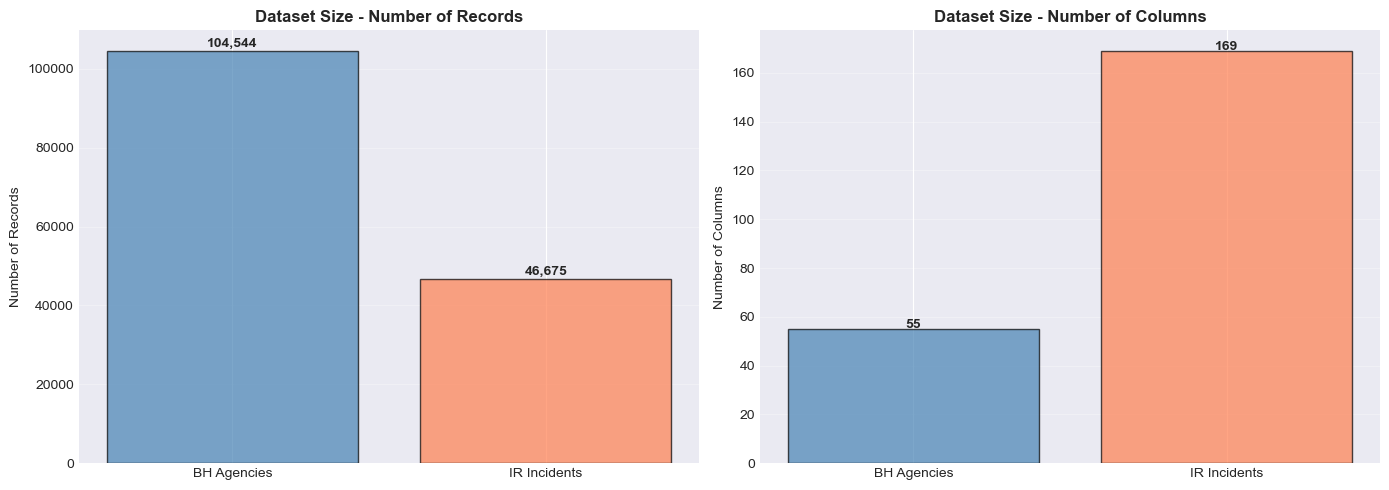

Saved: d:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\images\images_before\01_dataset_comparison.png


In [74]:
# Chart 1: Dataset Size Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ['BH Agencies', 'IR Incidents']
rows = [bh_decoded.shape[0], ir_decoded.shape[0]]
cols = [bh_decoded.shape[1], ir_decoded.shape[1]]

axes[0].bar(datasets, rows, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
axes[0].set_title('Dataset Size - Number of Records', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rows):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(datasets, cols, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
axes[1].set_title('Dataset Size - Number of Columns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Columns')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cols):
    axes[1].text(i, v + 0.5, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
# Save using the PROJECT_ROOT path where images folder was created
out_path = PROJECT_ROOT / 'images' / 'images_before' / '01_dataset_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {out_path}")

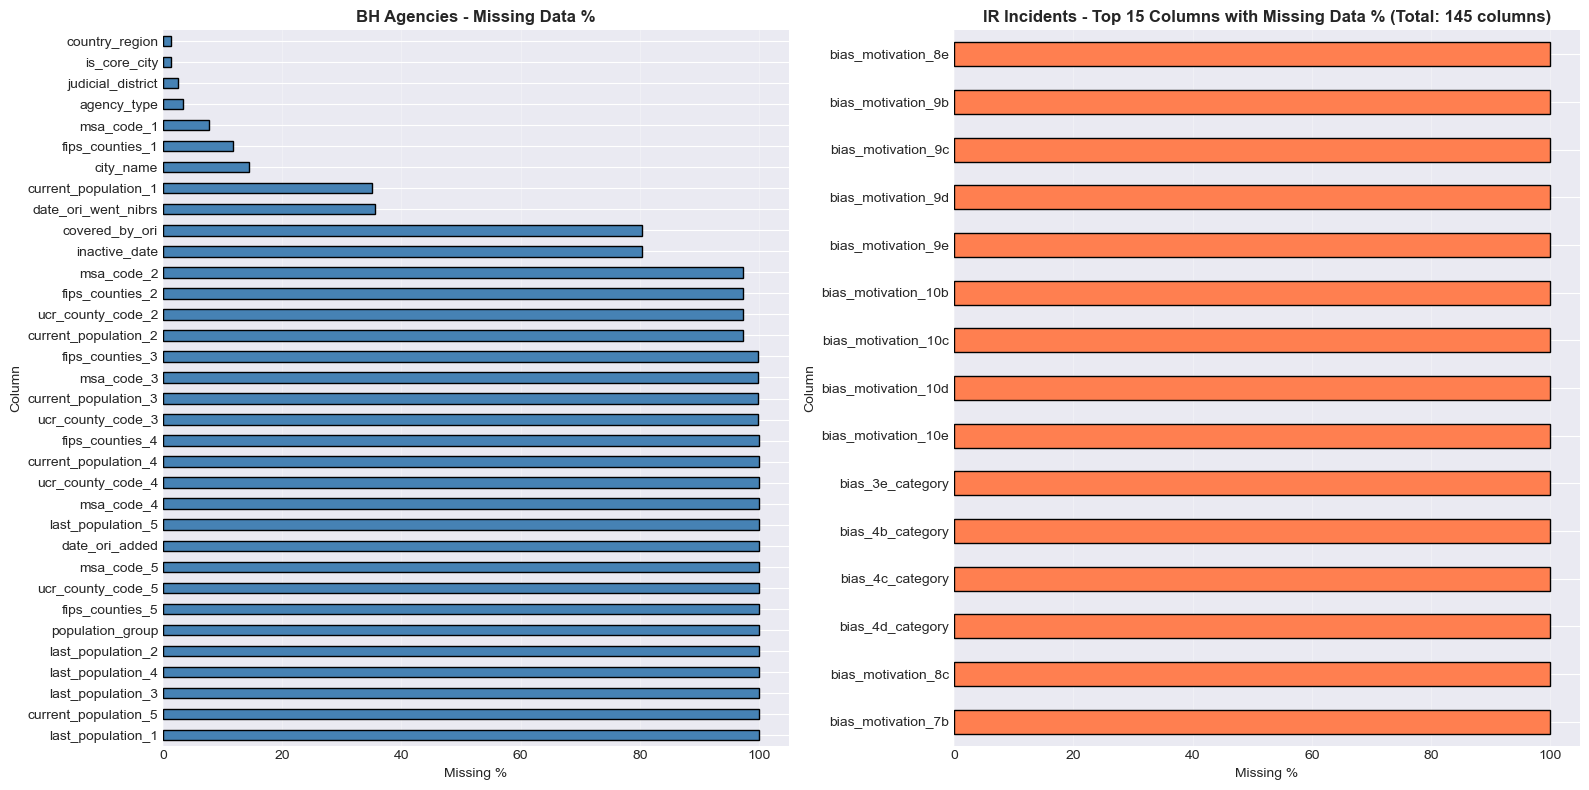

Saved: d:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\images\images_before\02_missing_data_comparison.png

Note: IR has 145 columns with missing data (checking for NaNs and empty strings).
Showing top 15 columns to maintain readability.


In [88]:
# Chart 2: Missing Data Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Prepare BH Data
# Use the DataFrame created in Part 2. Decoded Data Structure Exploration - BH Dataset
bh_plot_data = bh_missing_data[bh_missing_data['Percentage (%)'] > 0].copy()
# Set index to 'Column' so the plot labels are correct
bh_missing_pct = bh_plot_data.set_index('Column')['Percentage (%)']

# 2. Prepare IR Data 
# Use the DataFrame created in Part 3. Decoded Data Structure Exploration - IR Dataset
ir_plot_data = ir_missing_data[ir_missing_data['Percentage (%)'] > 0].copy()
ir_missing_pct = ir_plot_data.set_index('Column')['Percentage (%)']

# 3. Plotting

# --- Plot BH ---
if len(bh_missing_pct) > 0:
    bh_missing_pct.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('BH Agencies - Missing Data %', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Missing %')
    axes[0].grid(True, alpha=0.3, axis='x')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('BH Agencies - No Missing Data', fontsize=12, fontweight='bold')

# --- Plot IR ---
if len(ir_missing_pct) > 0:
    # For IR, show only top 15 columns with most missing data to avoid overlap
    ir_top = ir_missing_pct.head(15)
    ir_top.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title(f'IR Incidents - Top 15 Columns with Missing Data % (Total: {len(ir_missing_pct)} columns)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Missing %')
    axes[1].grid(True, alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('IR Incidents - No Missing Data', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save to the project's images folder
out_path = PROJECT_ROOT / 'images' / 'images_before' / '02_missing_data_comparison.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {out_path}")
print(f"\nNote: IR has {len(ir_missing_pct)} columns with missing data (checking for NaNs and empty strings).")
print(f"Showing top 15 columns to maintain readability.")

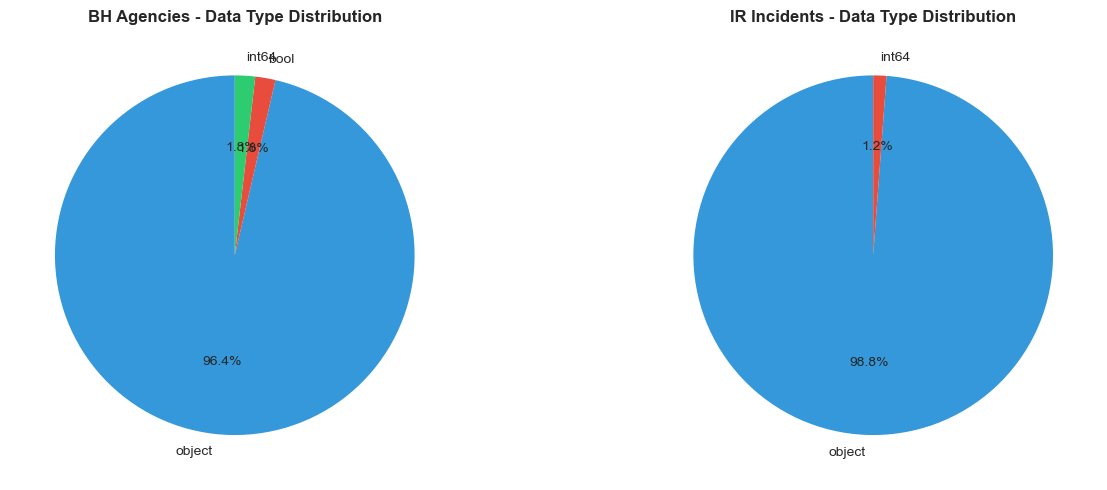

Saved: d:\Documents\DSEB\Data Prep and Visualization\final_prj\DPnV_Group5_DSEB\images\images_before\03_data_type_distribution.png


In [77]:
# Chart 3: Data Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bh_dtype_counts = bh_decoded.dtypes.value_counts()
ir_dtype_counts = ir_decoded.dtypes.value_counts()

colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].pie(bh_dtype_counts.values, labels=bh_dtype_counts.index, autopct='%1.1f%%', 
            colors=colors[:len(bh_dtype_counts)], startangle=90)
axes[0].set_title('BH Agencies - Data Type Distribution', fontweight='bold', fontsize=12)

axes[1].pie(ir_dtype_counts.values, labels=ir_dtype_counts.index, autopct='%1.1f%%', 
            colors=colors[:len(ir_dtype_counts)], startangle=90)
axes[1].set_title('IR Incidents - Data Type Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()

# Save to the project's images folder (use absolute path via PROJECT_ROOT)
out_path = PROJECT_ROOT / 'images' / 'images_before' / '03_data_type_distribution.png'
out_path.parent.mkdir(parents=True, exist_ok=True)  # ensure folder exists
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: {out_path}")

In [90]:
print("\n" + "="*80)
print("SUMMARY: DATA QUALITY ISSUES IN DECODED DATASETS")
print("="*80)

issues = [
    {
        'issue': 'Original files have encoding issues',
        'description': 'BH_raw and IR_raw files contain encoding problems and are not readable directly.',
        'severity': 'CRITICAL',
        'solution': 'Use decoded versions for all analysis'
    },
    {
        'issue': 'Data type inconsistencies',
        'description': 'Some columns may need type conversion (datetime, categorical, etc)',
        'severity': 'MEDIUM',
        'solution': 'Standardize data types in Phase 2'
    },
    {
        'issue': 'Missing values handling',
        'description': f'BH missing: {mask_missing_bh.sum().sum()}, IR missing: {base_mask_ir.sum().sum()}',
        'severity': 'MEDIUM',
        'solution': 'Develop strategy for missing value imputation or removal'
    }
]

for i, issue in enumerate(issues, 1):
    print(f"\n{'-'*70}")
    print(f"ISSUE {i}: {issue['issue']}")
    print(f"{'-'*70}")
    print(f"  Severity: {issue['severity']}")
    print(f"  Description: {issue['description']}")
    print(f"  Solution: {issue['solution']}")

print(f"\n{'='*80}")


SUMMARY: DATA QUALITY ISSUES IN DECODED DATASETS

----------------------------------------------------------------------
ISSUE 1: Original files have encoding issues
----------------------------------------------------------------------
  Severity: CRITICAL
  Description: BH_raw and IR_raw files contain encoding problems and are not readable directly.
  Solution: Use decoded versions for all analysis

----------------------------------------------------------------------
ISSUE 2: Data type inconsistencies
----------------------------------------------------------------------
  Severity: MEDIUM
  Description: Some columns may need type conversion (datetime, categorical, etc)
  Solution: Standardize data types in Phase 2

----------------------------------------------------------------------
ISSUE 3: Missing values handling
----------------------------------------------------------------------
  Severity: MEDIUM
  Description: BH missing: 2678076, IR missing: 6677272
  Solution: Develop